### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### Step 2: Load Dataset

In [10]:
df = fetch_openml(name='boston', version=1).data

In [22]:
df['Price'] = fetch_openml(name='boston', version=1).target

In [23]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [24]:
df.shape

(506, 14)

### Step 3: Exploring Data

In [29]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  Price    506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [28]:
pd.DataFrame({'na': df.isna().sum(), 'null': df.isnull().sum()}).T

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
na,0,0,0,0,0,0,0,0,0,0,0,0,0,0
null,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Step 4: Feature Engineering

In [19]:
category_list = df.select_dtypes(pd.CategoricalDtype).columns
float_list = df.select_dtypes(pd.Float64Dtype).columns

In [32]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [35]:
df_ohe = pd.DataFrame(ohe.fit_transform(df[category_list]), columns=ohe.get_feature_names_out())

In [40]:
df.drop(category_list, axis=1, inplace=True)

In [43]:
for col in float_list:
    if col == 'Price':
        continue
    scaler = StandardScaler()
    df[col] = scaler.fit_transform(df[[col]])

In [54]:
df = pd.concat([df, df_ohe], axis=1)

<Axes: >

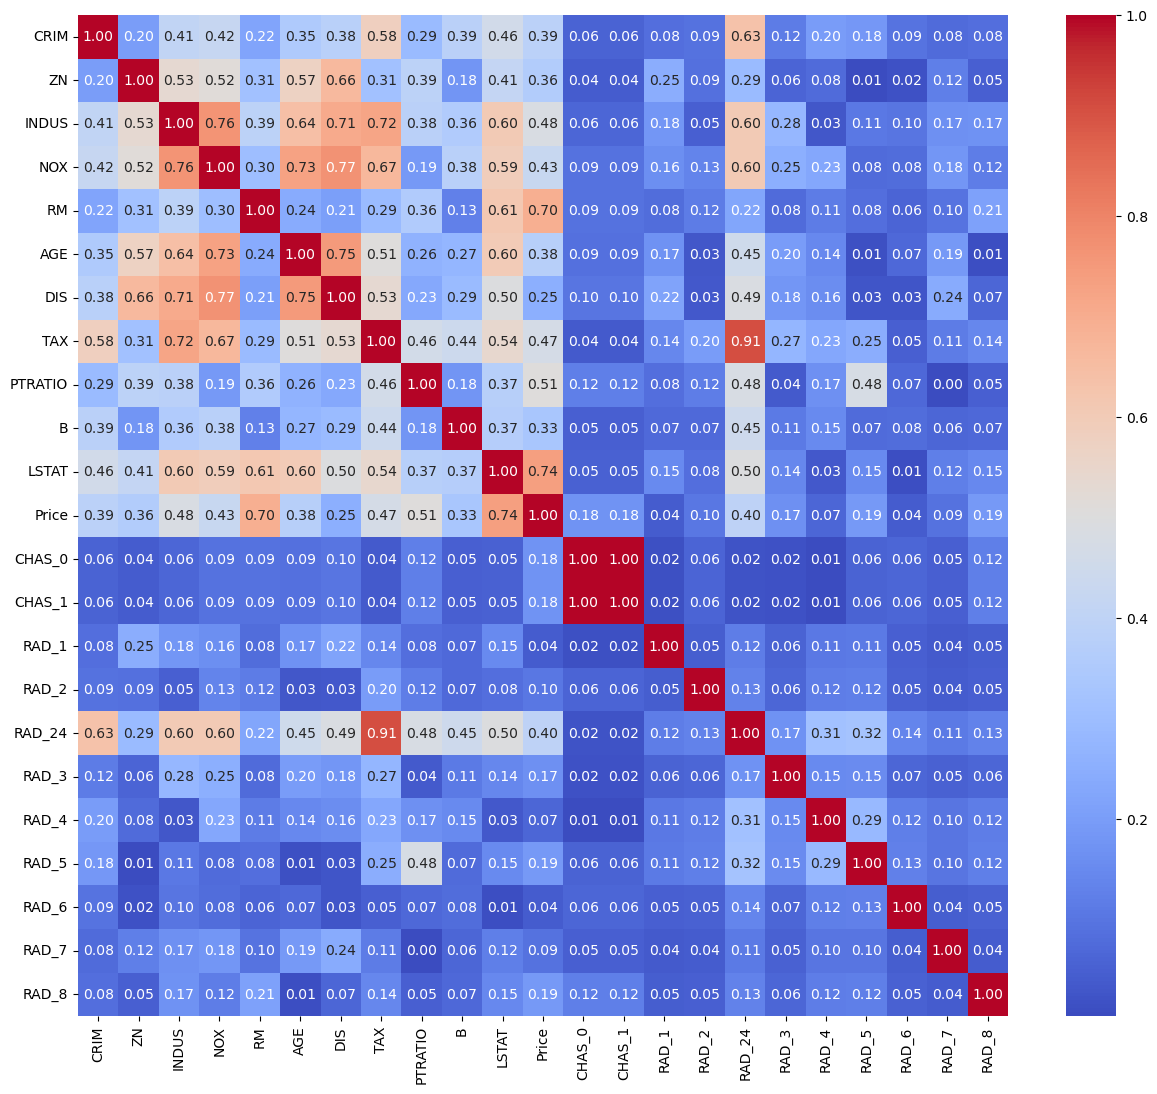

In [56]:
plt.figure(figsize=(15, 13))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.coolwarm
)

### Step 5: Preparing Data

In [58]:
features = df.drop(['Price'], axis=1)
target = df['Price']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

### Step 6: Building & Training Model

In [62]:
model = LinearRegression()

In [63]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Step 7: Evaluate Model

In [64]:
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'True value vs predicted value : Linear Regression')

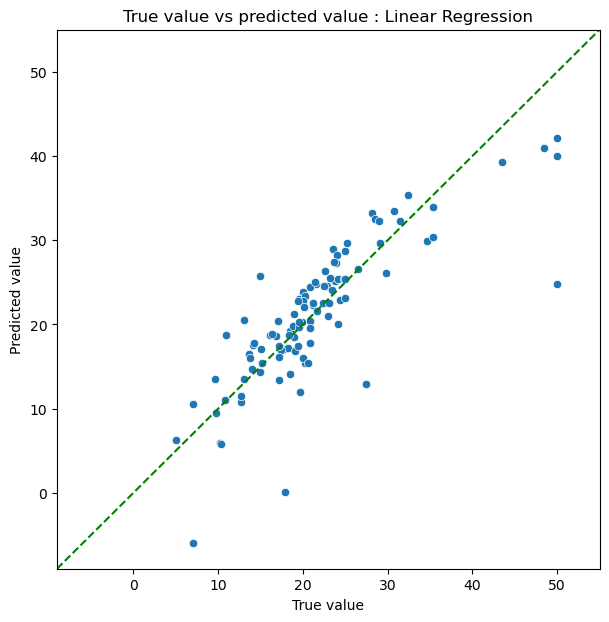

In [85]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([-9, 55], [-9, 55], '--', c='green')
plt.xlim(-9, 55)
plt.ylim(-9, 55)

plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("True value vs predicted value : Linear Regression")

In [66]:
mse = metrics.mean_squared_error(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)

In [67]:
print("Mean Square Error : ", mse)
print("Mean Absolute Error : ", mae)

Mean Square Error :  24.81844273848119
Mean Absolute Error :  3.3070847636664573
